# Wine Quality：模型擬合、評估與簡單調參

原始資料的 `quality` 是 3 到 8 分的品質評分。為了讓教學更容易理解，這裡把它轉成二元分類問題：

- `quality >= 6`：品質較佳，記為 `1`
- `quality < 6`：品質普通或偏低，記為 `0`



| 欄位名稱 | 中文說明 | 原始型態 | 資料角色 | 內容說明 | 缺漏值 | 建模時的處理建議 |
|---|---|---|---|---|---:|---|
| `fixed acidity` | 固定酸度 | `float64` | 數值特徵 | 酒中不容易揮發的酸，通常與酒的酸味有關 | 0 | 可直接作為模型特徵；若使用 Logistic Regression、KNN、SVM 等模型，建議標準化 |
| `volatile acidity` | 揮發性酸度 | `float64` | 數值特徵 | 揮發性酸含量，過高時可能造成刺鼻或醋味 | 0 | 可直接作為模型特徵；建議標準化 |
| `citric acid` | 檸檬酸 | `float64` | 數值特徵 | 檸檬酸可影響酒的清新感與酸味 | 0 | 可直接作為模型特徵 |
| `residual sugar` | 殘糖量 | `float64` | 數值特徵 | 發酵後殘留在酒中的糖分 | 0 | 可直接作為模型特徵；分布可能偏態 |
| `chlorides` | 氯化物 | `float64` | 數值特徵 | 酒中的鹽分相關指標 | 0 | 可直接作為模型特徵；可能有極端值 |
| `free sulfur dioxide` | 游離二氧化硫 | `float64` | 數值特徵 | 酒中未結合的二氧化硫，與抗氧化、防腐有關 | 0 | 可直接作為模型特徵 |
| `total sulfur dioxide` | 總二氧化硫 | `float64` | 數值特徵 | 游離與結合型二氧化硫總量 | 0 | 可直接作為模型特徵 |
| `density` | 密度 | `float64` | 數值特徵 | 酒的密度，可能與酒精濃度、糖分等有關 | 0 | 可直接作為模型特徵；數值範圍很小，標準化後較容易與其他特徵一起使用 |
| `pH` | 酸鹼值 | `float64` | 數值特徵 | 酒的酸鹼程度，pH 越低代表酸性越強 | 0 | 可直接作為模型特徵 |
| `sulphates` | 硫酸鹽 | `float64` | 數值特徵 | 與酒的保存、抗氧化特性有關 | 0 | 可直接作為模型特徵 |
| `alcohol` | 酒精濃度 | `float64` | 數值特徵 | 酒精含量百分比 | 0 | 常是重要特徵；可直接作為模型特徵 |
| `quality` | 品質評分 | `int64` | 目標欄位 | 酒的品質分數；此檔案中實際出現 3 到 8 分 | 0 | 可作為分類或迴歸任務的目標欄位 |

In [1]:
# ============================================================
# 1. 載入套件與讀取資料
# ============================================================
# 本資料集是以分號 ; 分隔，因此讀取時要設定 sep=";"。

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

# 讀取資料
# 使用時請確認 winequality.csv 和這個 notebook 放在同一個資料夾。
data = pd.read_csv("./winequality.csv", sep=";")

print("資料筆數與欄位數：")
print(data.shape)

print("前 5 筆資料：")
display(data.head())

資料筆數與欄位數：
(1599, 12)
前 5 筆資料：


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [2]:
# ============================================================
# 2. 初步檢查資料
# ============================================================
# 觀察欄位型態、遺漏值，以及 quality 的分布。

print("欄位型態：")
display(data.dtypes)

print("每個欄位的遺漏值數量：")
display(data.isna().sum())

print("quality 分布：")
quality_count = data["quality"].value_counts().sort_index()
display(quality_count)

欄位型態：


fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

每個欄位的遺漏值數量：


fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

quality 分布：


quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

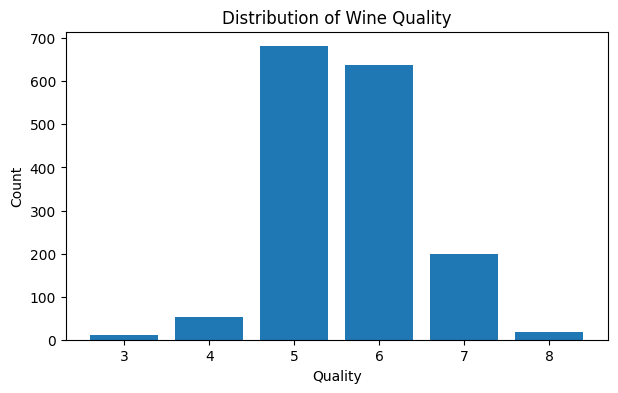

In [3]:
# ============================================================
# 3. 視覺化：觀察 wine quality 的分布
# ============================================================
# 這張圖可以看出大多數酒的 quality 集中在 5 和 6。

quality_count = data["quality"].value_counts().sort_index()

plt.figure(figsize=(7, 4))
plt.bar(quality_count.index, quality_count.values)
plt.xlabel("Quality")
plt.ylabel("Count")
plt.title("Distribution of Wine Quality")
plt.show()

good_quality 類別分布：


,類別,資料筆數
0,quality < 6,744
1,quality >= 6,855


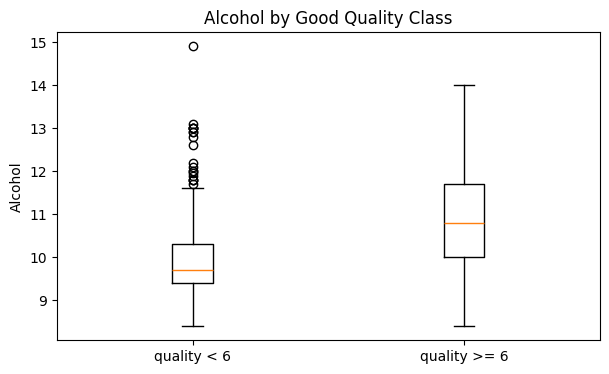

In [4]:
# ============================================================
# 4. 建立教學用目標欄位：good_quality
# ============================================================
# 原本 quality 是 3 到 8 分。
# 為了配合 Module 4 的分類模型教學，這裡轉成二元分類：
#   quality >= 6 代表品質較佳，記為 1
#   quality < 6 代表品質普通或偏低，記為 0

work_data = data.copy()
work_data["good_quality"] = (work_data["quality"] >= 6).astype(int)

print("good_quality 類別分布：")
good_quality_count = work_data["good_quality"].value_counts().sort_index()
good_quality_table = pd.DataFrame({
    "類別": ["quality < 6", "quality >= 6"],
    "資料筆數": [good_quality_count.get(0, 0), good_quality_count.get(1, 0)]
})
display(good_quality_table)

# 觀察 alcohol 和 good_quality 的關係。
# 從圖中通常可以看到品質較佳的酒，alcohol 往往偏高一些。
low_quality_alcohol = work_data.loc[work_data["good_quality"] == 0, "alcohol"]
high_quality_alcohol = work_data.loc[work_data["good_quality"] == 1, "alcohol"]

plt.figure(figsize=(7, 4))
plt.boxplot(
    [low_quality_alcohol, high_quality_alcohol],
    tick_labels=["quality < 6", "quality >= 6"]
)
plt.ylabel("Alcohol")
plt.title("Alcohol by Good Quality Class")
plt.show()

In [5]:
# ============================================================
# 5. 切分訓練資料與測試資料
# ============================================================
# X：所有理化特徵欄位
# y：是否為品質較佳的酒
#
# stratify=y 可以讓訓練資料和測試資料保留接近的類別比例。

feature_names = data.columns.drop("quality")

X = work_data[feature_names]
y = work_data["good_quality"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=0
)

print("訓練資料筆數：", X_train.shape[0])
print("測試資料筆數：", X_test.shape[0])

print("訓練資料類別分布：")
display(y_train.value_counts().sort_index())

print("測試資料類別分布：")
display(y_test.value_counts().sort_index())

訓練資料筆數： 1199
測試資料筆數： 400
訓練資料類別分布：


good_quality
0    558
1    641
Name: count, dtype: int64

測試資料類別分布：


good_quality
0    186
1    214
Name: count, dtype: int64

測試資料 F1-score： 0.7735849056603774
混淆矩陣：


,預測 quality < 6,預測 quality >= 6
實際 quality < 6,140,46
實際 quality >= 6,50,164


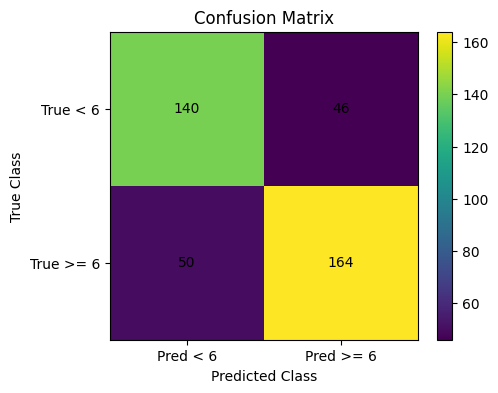

In [6]:
# ============================================================
# 6. 建立模型：StandardScaler + LogisticRegression
# ============================================================
# 為什麼要標準化？
#   winequality 的欄位單位不同，例如 alcohol、density、sulphates 的尺度差很多。
#   Logistic Regression 會受到特徵尺度影響，因此這裡使用 StandardScaler。
#
# Pipeline 可以把標準化和模型放在同一個流程中，避免資料前處理步驟漏掉。

model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=0))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

f1 = f1_score(y_test, y_pred)
print("測試資料 F1-score：", f1)

# 混淆矩陣不是本範例的主要評估指標，
# 但它可以幫助我們理解模型錯在哪裡。
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
cm_table = pd.DataFrame(
    cm,
    index=["實際 quality < 6", "實際 quality >= 6"],
    columns=["預測 quality < 6", "預測 quality >= 6"]
)

print("混淆矩陣：")
display(cm_table)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.xticks([0, 1], ["Pred < 6", "Pred >= 6"])
plt.yticks([0, 1], ["True < 6", "True >= 6"])
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix")

for row_index in range(cm.shape[0]):
    for column_index in range(cm.shape[1]):
        plt.text(column_index, row_index, cm[row_index, column_index], ha="center", va="center")

plt.colorbar()
plt.show()

5-fold cross validation 結果：


,fold,f1_score
0,1,0.794286
1,2,0.737805
2,3,0.761062
3,4,0.755162
4,5,0.735294


平均 F1-score： 0.7567217797544228
GridSearchCV 調參結果：


,C,mean_f1_score,std_f1_score
0,0.01,0.760691,0.013164
1,0.10,0.760293,0.018931
2,1.00,0.756722,0.021210
3,10.00,0.756465,0.019561
4,100.00,0.756465,0.019561


最佳 C： 0.01
最佳平均 F1-score： 0.7606907898012433


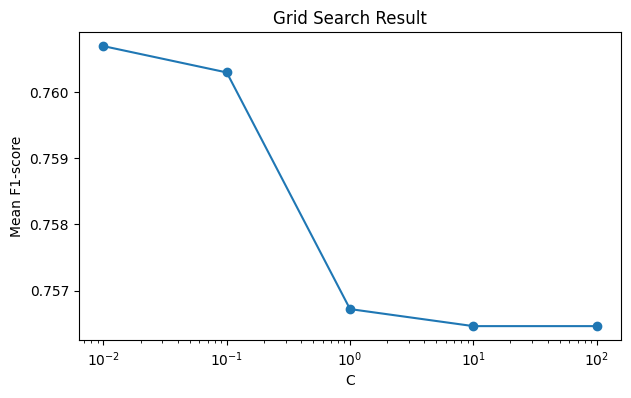

In [7]:
# ============================================================
# 7. K-fold Cross Validation 與簡單超參數調校
# ============================================================
# Module 4 的重點之一是：不要只依賴一次 train/test split。
# 這裡使用 5-fold cross validation 觀察 F1-score 是否穩定。
#
# 接著使用 GridSearchCV 調整 Logistic Regression 的 C。
# C 越小，正規化越強；C 越大，正規化越弱。

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="f1"
)

cv_result = pd.DataFrame({
    "fold": [1, 2, 3, 4, 5],
    "f1_score": cv_scores
})

print("5-fold cross validation 結果：")
display(cv_result)
print("平均 F1-score：", cv_scores.mean())

param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(
    model,
    param_grid=param_grid,
    cv=cv,
    scoring="f1"
)

grid_search.fit(X, y)

search_result = pd.DataFrame(grid_search.cv_results_)
search_result = search_result[["param_model__C", "mean_test_score", "std_test_score"]]
search_result = search_result.rename(columns={
    "param_model__C": "C",
    "mean_test_score": "mean_f1_score",
    "std_test_score": "std_f1_score"
})

print("GridSearchCV 調參結果：")
display(search_result)
print("最佳 C：", grid_search.best_params_["model__C"])
print("最佳平均 F1-score：", grid_search.best_score_)

plt.figure(figsize=(7, 4))
plt.plot(search_result["C"], search_result["mean_f1_score"], marker="o")
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Mean F1-score")
plt.title("Grid Search Result")
plt.show()